In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/split/trainval.csv')

df.shape

(56960, 31)

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,70320.0,-1.440536,-0.157661,1.951210,3.375675,1.076378,-1.049474,0.043954,0.063408,-1.379699,...,0.163049,0.035337,0.071452,0.710874,0.425002,0.353786,-0.007267,0.108108,62.38,0
1,36855.0,-0.268054,-0.026194,1.862894,-1.989876,-0.551961,-0.310759,0.277641,-0.160598,1.790869,...,0.201588,1.162627,-0.333368,0.171281,0.136557,-0.488836,0.063452,-0.095439,25.95,0
2,42436.0,-3.873686,2.279104,0.434901,-3.173945,-0.504830,0.029066,0.757593,-1.322265,2.122661,...,-0.771537,-1.354687,0.149311,-0.385015,-0.752701,0.449522,-3.542555,-1.439570,17.00,0
3,163977.0,-0.368752,0.922792,1.353228,2.461567,1.451856,2.942073,-0.074470,0.868245,-1.287337,...,0.445099,1.458492,-0.033405,-1.841053,-0.690577,0.123031,0.028285,0.027508,0.00,0
4,130811.0,2.258621,-1.431942,-0.567731,-1.431582,-1.627116,-0.924648,-1.228725,-0.224030,-1.030023,...,-0.137722,0.117330,0.253277,0.026271,-0.289235,-0.179701,0.024791,-0.042692,25.00,0


**From here data isn't scaled**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56960 entries, 0 to 56959
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    56960 non-null  float64
 1   V1      56960 non-null  float64
 2   V2      56960 non-null  float64
 3   V3      56960 non-null  float64
 4   V4      56960 non-null  float64
 5   V5      56960 non-null  float64
 6   V6      56960 non-null  float64
 7   V7      56960 non-null  float64
 8   V8      56960 non-null  float64
 9   V9      56960 non-null  float64
 10  V10     56960 non-null  float64
 11  V11     56960 non-null  float64
 12  V12     56960 non-null  float64
 13  V13     56960 non-null  float64
 14  V14     56960 non-null  float64
 15  V15     56960 non-null  float64
 16  V16     56960 non-null  float64
 17  V17     56960 non-null  float64
 18  V18     56960 non-null  float64
 19  V19     56960 non-null  float64
 20  V20     56960 non-null  float64
 21  V21     56960 non-null  float64
 22

- Time → Number of seconds elapsed between this transaction and the first transaction in the dataset.

- V1–V28 → PCA-transformed features.

- Amount → transaction value.

- Class → target (0 = normal, 1 = fraud).

- All predictors are numeric, target is binary (int64).

**No missing data and no object features except target feature which is the class**

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,56960.0,94618.777633,47567.353857,4.000000,53925.250000,84559.000000,139385.250000,172788.000000
V1,56960.0,0.008241,1.928594,-35.274010,-0.916434,0.026847,1.318466,2.418802
V2,56960.0,0.009452,1.610555,-44.639245,-0.600371,0.069277,0.811323,17.418649
V3,56960.0,0.004196,1.493492,-31.813586,-0.887902,0.184420,1.024113,4.101716
V4,56960.0,-0.001807,1.414919,-5.416315,-0.856074,-0.030007,0.747237,12.699542
V5,56960.0,0.003572,1.350720,-29.730600,-0.688001,-0.053001,0.614933,31.457046
V6,56960.0,-0.004865,1.325396,-21.248752,-0.773573,-0.283597,0.390776,21.307738
V7,56960.0,-0.007557,1.183066,-31.197329,-0.557624,0.037480,0.568802,31.527244
V8,56960.0,0.001075,1.205519,-50.943369,-0.208778,0.023736,0.331706,20.007208
V9,56960.0,0.003971,1.094351,-9.462573,-0.639260,-0.050270,0.602992,10.370658


In [6]:
df.skew()

Time      -0.032295
V1        -3.006682
V2        -3.873579
V3        -2.038689
V4         0.632194
V5        -0.109439
V6         1.209437
V7        -0.825384
V8        -7.845620
V9         0.589578
V10        1.508057
V11        0.352335
V12       -2.228825
V13        0.067126
V14       -1.918372
V15       -0.333727
V16       -1.076885
V17       -3.433069
V18       -0.245582
V19        0.123736
V20       -1.631008
V21        3.774720
V22       -0.245401
V23      -12.582292
V24       -0.589505
V25       -0.496233
V26        0.591864
V27       -1.273620
V28        4.174198
Amount    10.830096
Class     25.098280
dtype: float64

1. Time

- Mean ≈ 94,618 with range 4 → 172,788.

- Near zero skew (-0.03) → roughly symmetric distribution.

2. PCA Features (V1–V28)

    - Most have mean ≈ 0 and std ≈ 1 (as expected from PCA scaling).

    - Many features are negatively skewed (e.g., V1, V2, V3, V8, V12, V14, V17, V20, V23, V27).

    - A few are positively skewed (e.g., V4, V6, V9, V10, V11, V19, V21, V26, V28).

    - Notable extremes:

      - V8 (-7.84) and V23 (-12.58) → highly negatively skewed.

      - V21 (3.77) and V28 (4.17) → highly positively skewed.

These extreme skews may indicate outliers or non-Gaussian distributions.

3. Amount

- Mean ≈ 86.7, median ≈ 21.9, max ≈ 11,789.

- Highly positively skewed (10.83) → lots of small transactions with few very large ones.

- Strong candidate for log transformation if modeling.

4. Class (Target)

- Mean ≈ 0.00158 → only ~0.16% of transactions are fraud.

- Extremely skewed (25.09) → confirms severe class imbalance.

- Will need special handling: oversampling (SMOTE), undersampling, or class-weighted models.

In [7]:
df.duplicated().sum()

np.int64(62)

**62 duplicated rows**

In [8]:
df['Class'].value_counts()

Class
0    56870
1       90
Name: count, dtype: int64

**0.158% percentage of positive class**

# Distribution of Amount

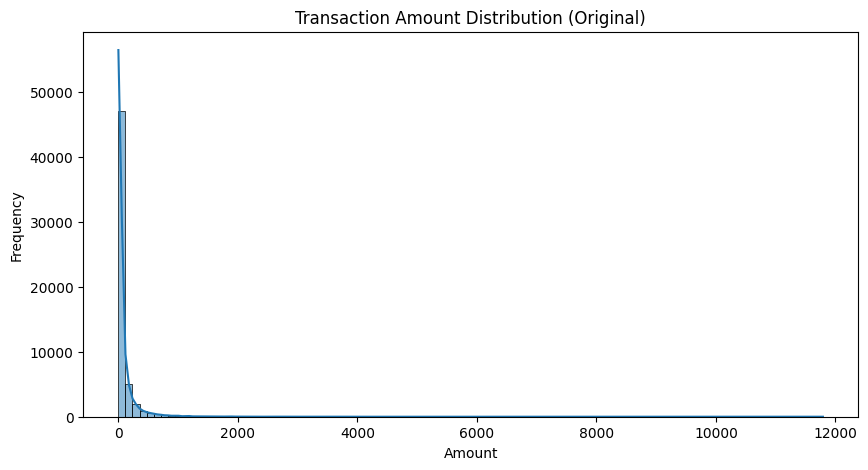

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df['Amount'], bins=100, kde=True)
plt.title("Transaction Amount Distribution (Original)")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# 2. Distribution of Amount (log-transformed to reduce skew)

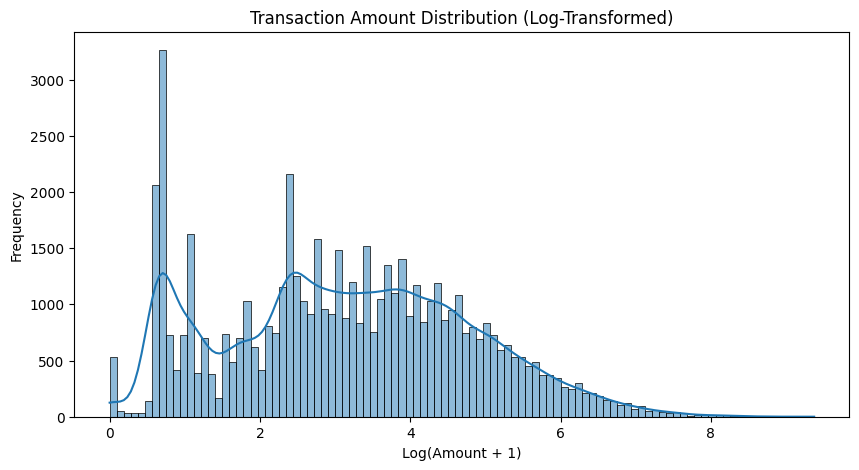

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df['Amount']), bins=100, kde=True)
plt.title("Transaction Amount Distribution (Log-Transformed)")
plt.xlabel("Log(Amount)")
plt.ylabel("Frequency")
plt.show()

# 3. Boxplot of Amount by Class

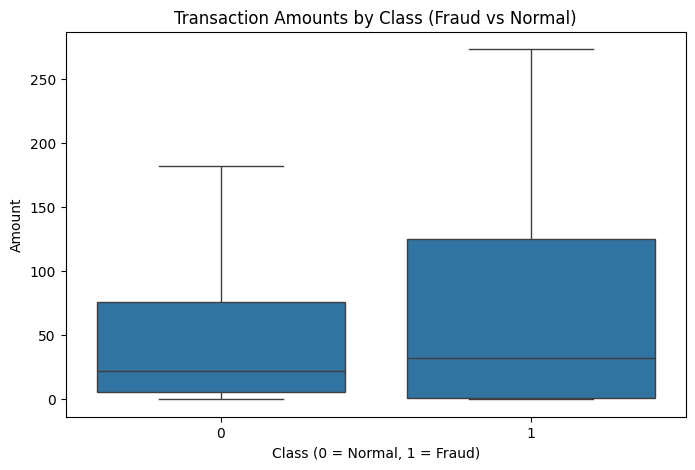

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df, showfliers=False)  # hide extreme outliers for readability
plt.title("Transaction Amounts by Class (Fraud vs Normal)")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Amount")
plt.show()

**Fraud transactions usually contain more amount than normal transactions**

# 4. KDE plot to compare fraud vs normal

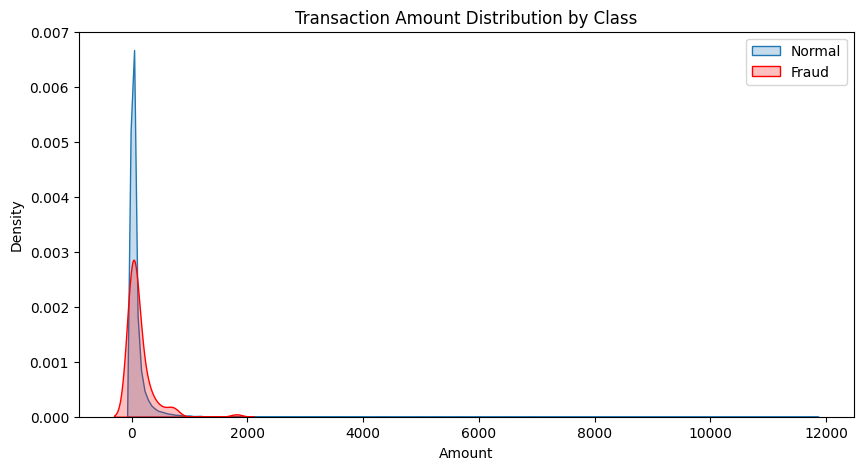

In [12]:
plt.figure(figsize=(10,5))
sns.kdeplot(df[df['Class']==0]['Amount'], label="Normal", fill=True)
sns.kdeplot(df[df['Class']==1]['Amount'], label="Fraud", fill=True, color="red")
plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.legend()
plt.show()

# Distribution of Time (all transactions)

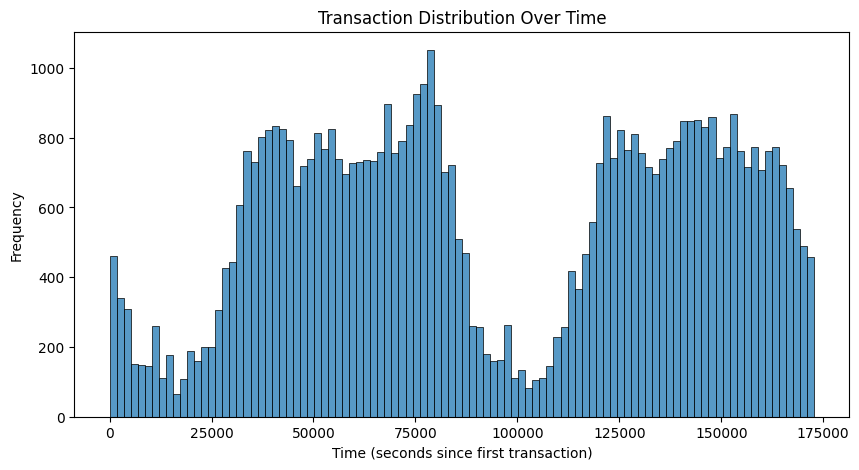

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Time'], bins=100, kde=False)
plt.title("Transaction Distribution Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")
plt.show()

# Distribution of Time by Class

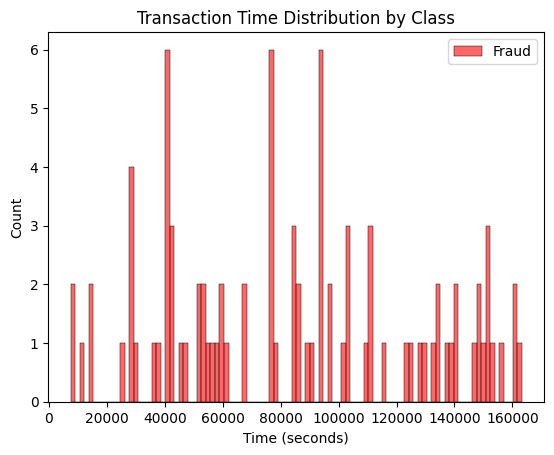

In [23]:
sns.histplot(df[df['Class']==1]['Time'], bins=100, color="red", label="Fraud", alpha=0.6)
plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time (seconds)")
plt.ylabel("Count")
plt.legend()
plt.show()